In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_sales.csv')

In [23]:
df["sales_representative"].value_counts()

sales_representative
Sophia Brown        1158
Olivia Martin       1143
Emma Carter         1143
Amelia Jackson      1142
Michael Clark       1142
Lucas Moore         1133
Noah Wilson         1121
Henry White         1121
Grace Harris        1119
Mia Taylor          1116
James Anderson      1108
Liam Davis          1108
Daniel Miller       1095
Ella Lewis          1093
Charlotte Thomas    1071
David Walker        1067
Name: count, dtype: int64

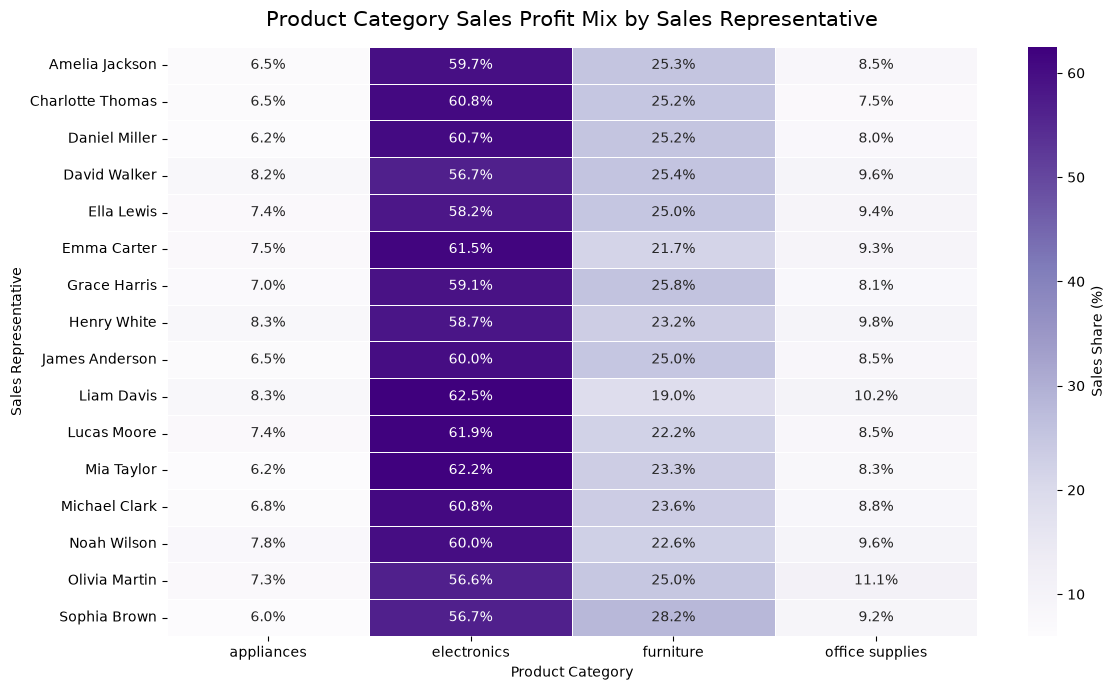

In [18]:
rep_category = (
    df.groupby(["sales_representative", "product_category"])["sales_amount"]
      .sum()
      .unstack(fill_value=0)
)

rep_share = rep_category.div(rep_category.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 7))

sns.heatmap(
    rep_share,
    annot=rep_share.map(lambda x: f"{x:.1f}%"),
    fmt="",
    cmap="Purples",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Sales Share (%)"}
)

plt.title(
    "Product Category Sales Profit Mix by Sales Representative",
    fontsize=15,
    pad=15
)

plt.xlabel("Product Category")
plt.ylabel("Sales Representative")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[14, 22, 30, 50, float("inf")],
    labels=["Teenagers", "Young Adults", "Middle Age", "Older Adults"]
)

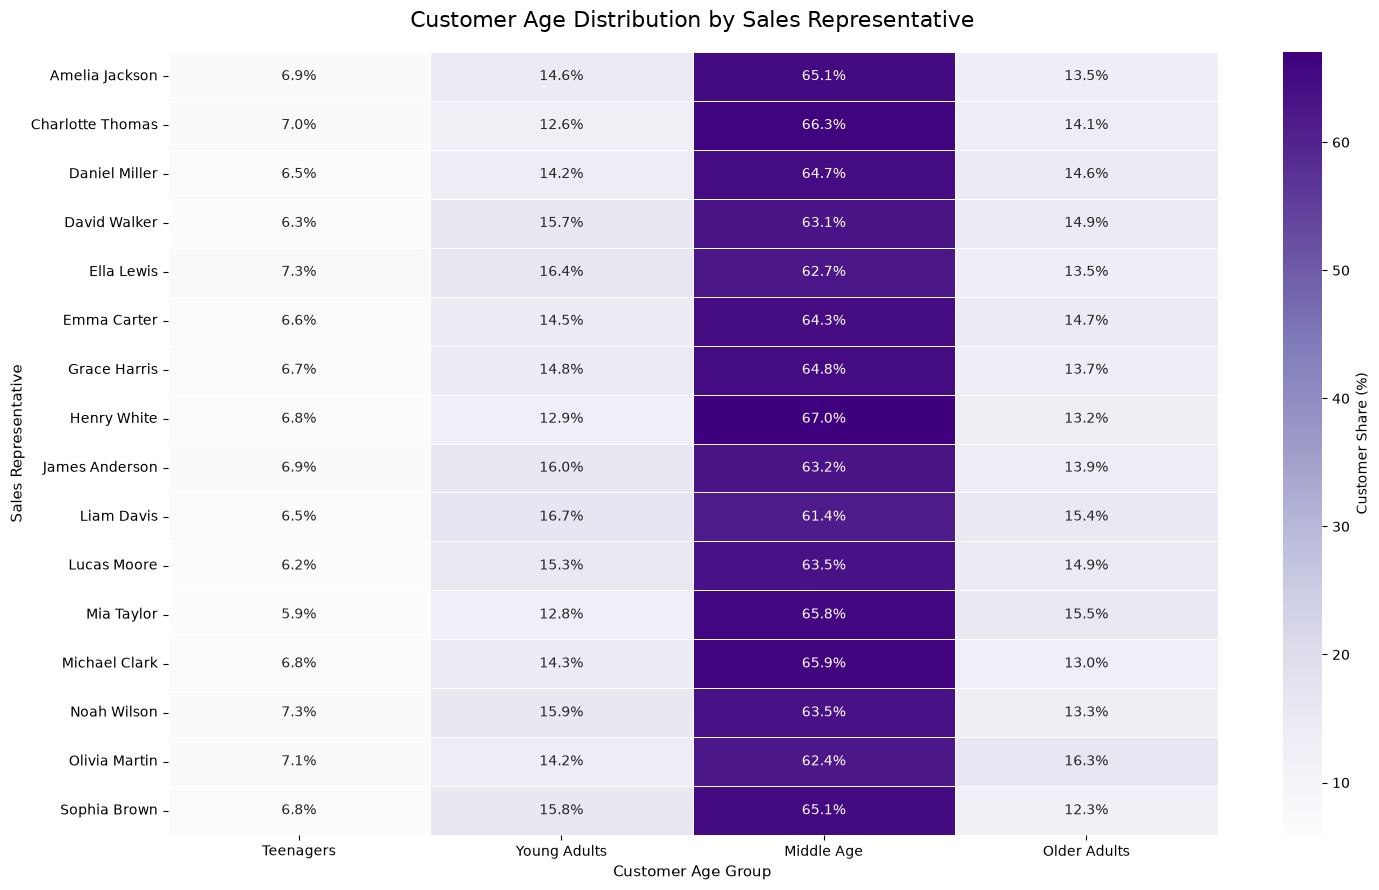

In [13]:
age_rep = (
    df.groupby(["sales_representative", "age_group"])["customer_id"]
      .nunique()
      .unstack(fill_value=0)
)

age_rep_pct = age_rep.div(age_rep.sum(axis=1), axis=0) * 100

plt.figure(figsize=(15, 9))

sns.heatmap(
    age_rep_pct,
    annot=age_rep_pct.map(lambda x: f"{x:.1f}%"),
    fmt="",
    cmap="Purples",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Customer Share (%)"}
)

plt.title(
    "Customer Age Distribution by Sales Representative",
    fontsize=16,
    pad=18
)

plt.xlabel("Customer Age Group", fontsize=11)
plt.ylabel("Sales Representative", fontsize=11)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

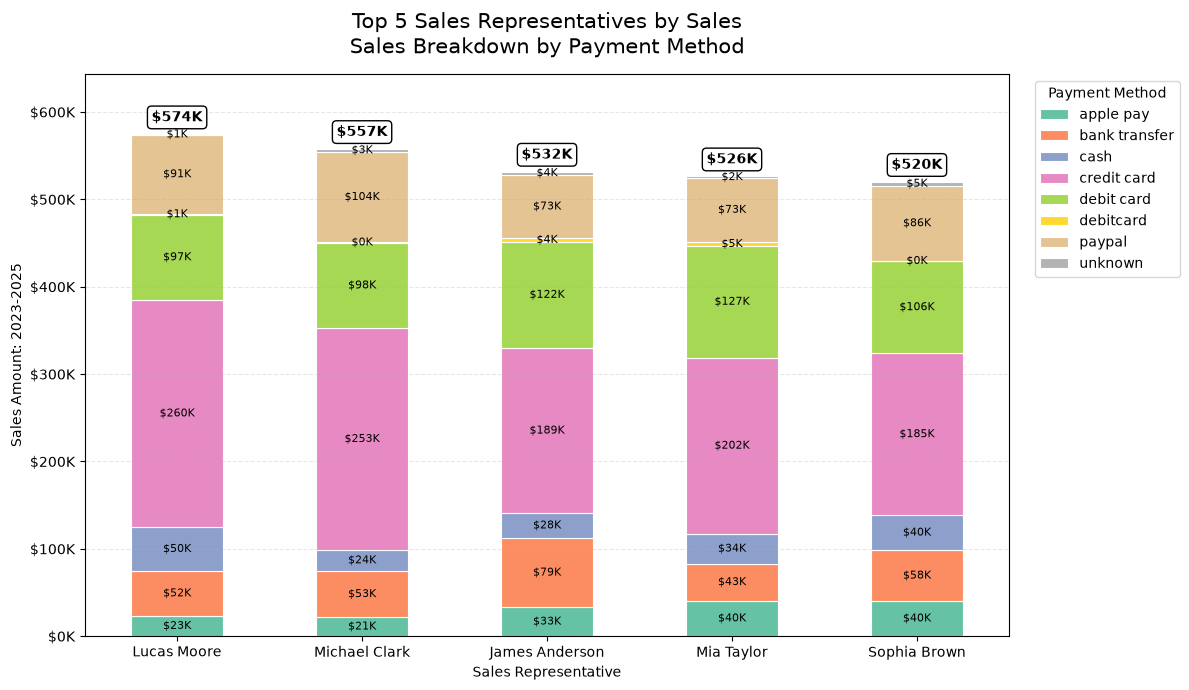

In [9]:
from matplotlib.ticker import FuncFormatter

top_reps = (
    df.groupby("sales_representative")["sales_amount"]
      .sum()
      .nlargest(5)
      .index
)

plot_df = (
    df[df["sales_representative"].isin(top_reps)]
    .groupby(["sales_representative", "payment_method"])["sales_amount"]
    .sum()
    .unstack(fill_value=0)
)

plot_df = plot_df.loc[
    plot_df.sum(axis=1).sort_values(ascending=False).index
]

colors = sns.color_palette("Set2", n_colors=len(plot_df.columns))

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    color=colors,
    edgecolor="white",
    linewidth=0.8
)


def money_fmt(x):
    if abs(x) >= 1_000_000:
        return f"${x / 1_000_000:.1f}M"
    return f"${x / 1_000:.0f}K"


# Stack ichidagi labels
for container in ax.containers:
    labels = [
        money_fmt(v) if v > 0 else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        color="black"
    )


# Total label — har bir stack tepasida
totals = plot_df.sum(axis=1)

for i, total in enumerate(totals):
    ax.annotate(
        money_fmt(total),
        (i, total),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            linewidth=1
        )
    )


ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: money_fmt(x))
)

plt.title(
    "Top 5 Sales Representatives by Sales\n"
    "Sales Breakdown by Payment Method",
    fontsize=15,
    pad=15
)

plt.xlabel("Sales Representative")
plt.ylabel("Sales Amount: 2023-2025")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Payment Method",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.ylim(0, totals.max() * 1.12)

plt.tight_layout()
plt.show()

In [19]:
category_profile = (
    df.groupby("product_category")
      .agg(
          target_age_group=("age_group", lambda x: x.value_counts().idxmax()),
          best_sales_rep=("sales_representative", lambda x: x.value_counts().idxmax())
      )
      .reset_index()
)

category_profile["rep_total_orders"] = category_profile["best_sales_rep"].map(
    df["sales_representative"].value_counts()
)

category_profile["category_orders"] = [
    ((df["product_category"] == cat) &
     (df["sales_representative"] == rep)).sum()
    for cat, rep in zip(
        category_profile["product_category"],
        category_profile["best_sales_rep"]
    )
]

category_profile["category_share %"] = (
    category_profile["category_orders"]
    / category_profile["rep_total_orders"] * 100
).round(1)

category_profile

,product_category,target_age_group,best_sales_rep,rep_total_orders,category_orders,category_share %
0,appliances,Middle Age,Sophia Brown,1158,135,11.7
1,electronics,Middle Age,Liam Davis,1108,526,47.5
2,furniture,Middle Age,Sophia Brown,1158,228,19.7
3,office supplies,Middle Age,Olivia Martin,1143,311,27.2


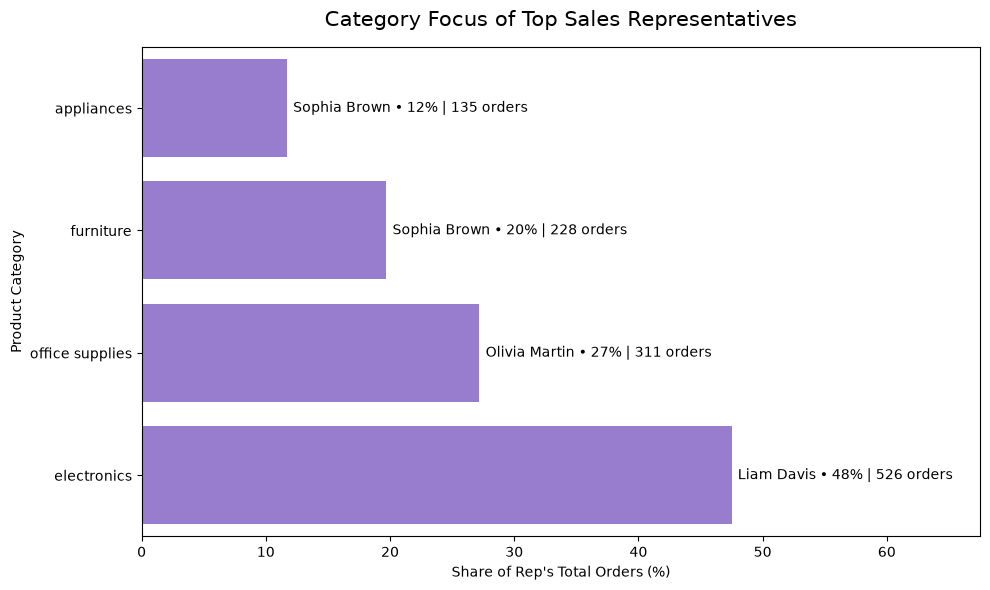

In [21]:
plot_df = category_profile.sort_values("category_share %")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df,
    x="category_share %",
    y="product_category",
    color="mediumpurple"
)

for i, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(
        row["category_share %"] + 0.5,
        i,
        f'{row["best_sales_rep"]} • {row["category_share %"]:.0f}% | {row["category_orders"]} orders',
        va="center",
        fontsize=10
    )

plt.title("Category Focus of Top Sales Representatives", fontsize=15, pad=15)
plt.xlabel("Share of Rep's Total Orders (%)")
plt.ylabel("Product Category")

plt.xlim(0, plot_df["category_share %"].max() + 20)
plt.tight_layout()
plt.show()